<a href="https://colab.research.google.com/github/SinBoYang/data-science/blob/main/FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 期末專案：長照 2.0 資源分布深度分析與供需塑模
### 姓名：楊信柏
### 學號：112403515
### Colab link：[https://colab.research.google.com/drive/18tdv0PCfrHVL83mrTyDoW69gpD7uKOFv?usp=sharing]
### Github link：[https://github.com/SinBoYang/data-science]

---
## 1. 專案背景、動機與資料來源 (Topic, Motivations & Data sources)

**研究動機 (Motivations)：**
隨著台灣邁入超高齡社會，長照 2.0 積極佈建 A、B、C 級據點。然而，資源的增加是否真能滿足各縣市實際的「高齡人口需求」？偏鄉與都會區是否有系統性的資源錯配？本專案旨在透過資料探勘與統計建模，揭露長照資源在空間與人口結構上的分配現況，並評估長照系統整合的潛在壓力。

**資料來源 (Data Sources)：**
本專案整合了兩份真實的開放政府資料：
1. **長照服務機構清單 (`abc.csv`)**：提供各機構所在縣市、等級 (O_ABC)、經緯度、開放床數與收容人數，作為「供給端」數據。
2. **各縣市人口年齡結構 (`population_202602.csv`)**：擷取 115 年 2 月底各縣市「65歲以上高齡人口數」，作為「需求端」的基準。

## 2. 專案環境與套件需求 (Requirements)

- Python: 3.12.x
- Packages: `pandas`, `numpy`, `matplotlib`, `seaborn`, `folium`, `scikit-learn`

In [ ]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


#  Data analysis and modeling

## Part 1 資料集載入及處理





In [18]:
import pandas as pd

url_abc = 'https://raw.githubusercontent.com/SinBoYang/data-science/refs/heads/main/long-term-care-2.0/abc.csv'
url_pop = 'https://raw.githubusercontent.com/SinBoYang/data-science/refs/heads/main/long-term-care-2.0/population_202602.csv'

# 載入供給端資料 (長照機構)
df_abc = pd.read_csv(url_abc)

# 從地址全址擷取前三個字作為縣市名稱
df_abc['縣市名稱'] = df_abc['地址全址'].astype(str).str[:3]

df_abc['開放床數'] = pd.to_numeric(df_abc['開放床數'], errors='coerce').fillna(0)
df_abc['現有住民'] = pd.to_numeric(df_abc['現有住民'], errors='coerce').fillna(0)
df_abc['經度'] = pd.to_numeric(df_abc['經度'], errors='coerce')
df_abc['緯度'] = pd.to_numeric(df_abc['緯度'], errors='coerce')
df_abc = df_abc.dropna(subset=['O_ABC'])

# 載入需求端資料 (高齡人口)
df_pop_raw = pd.read_csv(url_pop, header=None, skiprows=4)
df_pop = df_pop_raw.iloc[:, [0, 28]].copy()
df_pop.columns = ['縣市名稱', '65歲以上人口數']

# 清理字串：移除空白、千位數逗號與統計總列
df_pop['縣市名稱'] = df_pop['縣市名稱'].astype(str).str.replace(' ', '')
df_pop = df_pop[~df_pop['縣市名稱'].str.contains('總計|臺灣省|福建省')]
df_pop['65歲以上人口數'] = pd.to_numeric(df_pop['65歲以上人口數'].astype(str).str.replace(',', ''), errors='coerce')
print(df_abc.head(5))
print("\n")
print(df_pop.head(5))


                                                機構名稱       機構代碼 機構種類     縣市  \
0  財團法人台南市基督教青年會社會福利慈善事業基金會附設臺南市私立YMCA居家式服務類長期照顧服務機構  1S1500012    1  67000   
1                     有限責任高雄市健康照顧服務勞動合作社附設私立健康居家長照機構  1T1500001    1  64000   
2             社團法人高雄市樂齡照顧關懷協會附設高雄市私立樂齡居家式服務類長期照顧服務機構  1R1500007    1  64000   
3          有限責任高雄市日新照顧服務勞動合作社附設高雄市私立日新居家式服務類長期照顧服務機構  1T1500007    1  64000   
4        財團法人高雄市華仁社會福利慈善事業基金會附設高雄市私立華仁居家式服務類長期照顧服務機構  1S1500007    1  64000   

            區                  地址全址          經度         緯度 O_ABC  特約服務項目  ...  \
0  67000320.0    臺南市東區大同里大同路一段59號5樓  120.211418  22.987473     B  營養餐飲服務  ...   
1  64000050.0  高雄市三民區寶珠里正忠路455巷4之2號  120.330170  22.650312     B    喘息服務  ...   
2  64000190.0       高雄市岡山區竹圍東街81號1樓  120.304298  22.801668     B  營養餐飲服務  ...   
3  64000310.0      高雄市美濃區泰安里双峰街6之3號  120.540009  22.910650     B  營養餐飲服務  ...   
4  64000250.0   高雄市湖內區大湖里長壽路65巷6弄1號  120.244102  22.884644     B  營養餐飲服務  ...   

                        電子郵件 機構負責人姓名  

## Part 2 : 敘述性統計分析 (Summary Statistics)

In [20]:
print("=== 1. 長照機構級別結構統計 ===")
abc_counts = df_abc['O_ABC'].value_counts()
for level, count in abc_counts.items():
    print(f"{level} 級據點: {count} 家 (佔比: {(count / len(df_abc)) * 100:.1f}%)")

print("\n=== 2. 全台長照資源量能統計 ===")
total_beds = df_abc['開放床數'].sum()
total_residents = df_abc['現有住民'].sum()
occupancy_rate = (total_residents / total_beds * 100) if total_beds > 0 else 0
print(f"總開放床數: {total_beds:,.0f} 床 | 現有服務人數: {total_residents:,.0f} 人 | 整體供需比: {occupancy_rate:.2f}%")

print("\n=== 3. 跨資料集分析：縣市長照資源充足率 ===")
# 計算各縣市總開放床數並與高齡人口合併
city_beds = df_abc.groupby('縣市名稱')['開放床數'].sum().reset_index()
df_merged = pd.merge(df_pop, city_beds, on='縣市名稱', how='inner')

# 計算每百位老人擁有的床位數
df_merged['每百位老人床位數'] = (df_merged['開放床數'] / df_merged['65歲以上人口數']) * 100
display(df_merged.sort_values(by='每百位老人床位數', ascending=True).head(5))

=== 1. 長照機構級別結構統計 ===
B 級據點: 25949 家 (佔比: 83.1%)
C 級據點: 4234 家 (佔比: 13.6%)
A 級據點: 1037 家 (佔比: 3.3%)

=== 2. 全台長照資源量能統計 ===
總開放床數: 171,145 床 | 現有服務人數: 791,025 人 | 整體供需比: 462.20%

=== 3. 跨資料集分析：縣市長照資源充足率 ===


,縣市名稱,65歲以上人口數,開放床數,每百位老人床位數
1,臺北市,592649.0,8726,1.472372
17,基隆市,80745.0,1501,1.858939
5,高雄市,569133.0,10792,1.896218
0,新北市,813604.0,16986,2.087748
8,苗栗縣,108229.0,2854,2.637001


## Part 3 : 資料視覺化 (Visualization)

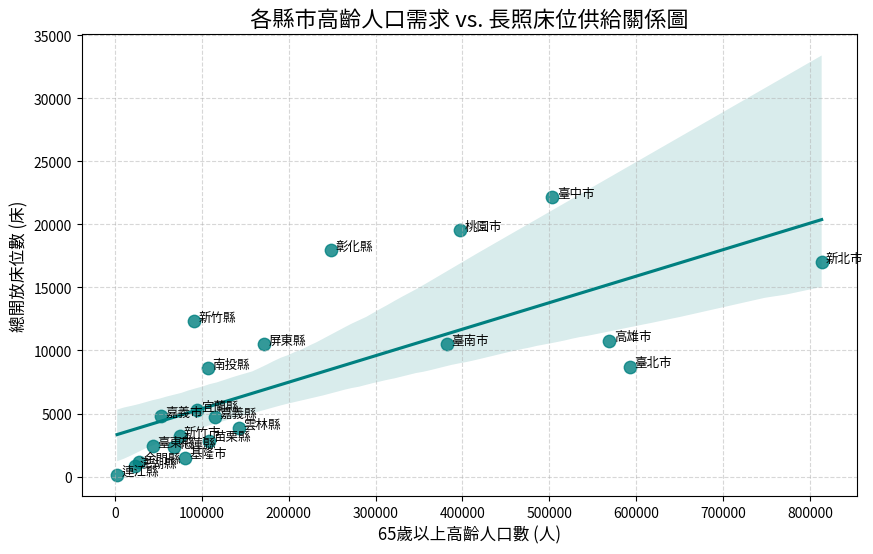


【全台長照資源空間熱力圖】


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
import matplotlib as mpl
import matplotlib.font_manager as fm
import urllib.request
import os

# Colab 中文字型設定
font_path = '/tmp/TaipeiSansTCBeta-Regular.ttf'
if not os.path.exists(font_path):
    urllib.request.urlretrieve('https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download', font_path)
fm.fontManager.addfont(font_path)
mpl.rc('font', family='Taipei Sans TC Beta')
plt.rcParams['axes.unicode_minus'] = False

# --- 圖表 1：高齡人口 vs 長照床位供給散佈圖 ---
plt.figure(figsize=(10, 6))
sns.regplot(x='65歲以上人口數', y='開放床數', data=df_merged, scatter_kws={'s':80}, color='teal')

for i in range(df_merged.shape[0]):
    plt.text(x=df_merged['65歲以上人口數'].iloc[i] + 5000,
             y=df_merged['開放床數'].iloc[i],
             s=df_merged['縣市名稱'].iloc[i],
             fontsize=9)

plt.title('各縣市高齡人口需求 vs. 長照床位供給關係圖', fontsize=16, fontweight='bold')
plt.xlabel('65歲以上高齡人口數 (人)', fontsize=12)
plt.ylabel('總開放床位數 (床)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# --- 圖表 2：全台長照據點熱力圖 ---
print("\n【全台長照資源空間熱力圖】")
df_map = df_abc.dropna(subset=['緯度', '經度'])
m = folium.Map(location=[23.6978, 120.9605], zoom_start=7, tiles='CartoDB positron')

heat_data = [[row['緯度'], row['經度']] for index, row in df_map.iterrows()]
HeatMap(heat_data, radius=10, blur=15, max_zoom=1).add_to(m)
display(m)

### 視覺化分析洞察 (Visualization finding)

透過人口供需散佈圖與地理熱力圖的交叉比對，本專案得出以下兩個核心發現：

**1. 供需失衡的潛在危機（基於散佈圖分析）：**
* **總體趨勢**：高齡人口數與長照床位供給量整體呈現正相關（符合線性迴歸趨勢），顯示政府資源確實有隨著人口基數而增加。
* **異常點 (Outliers) 揭露**：
  * **臺北市的資源緊繃**：身為首善之都的「臺北市」，其 65 歲以上高齡人口高居全台第二（逼近 60 萬人），但其總開放床位數卻明顯低於趨勢線，甚至低於人口數較少的臺中市與高雄市。這暗示臺北市可能面臨嚴重的「寸土寸金導致機構建置困難」，長照床位供需比極度吃緊。
  * **新北市的重擔**：新北市位居圖表最右上角，雖然床位數全台最多，但高齡人口也突破 80 萬大關，其絕對數值的壓力依然龐大。

**2. 資源空間極化與城鄉差距（基於地理熱力圖分析）：**
* **高度都會區集中**：熱力圖強烈顯示，台灣的長照據點極度集中於「西部都會走廊」（北北桃、臺中、臺南、高雄都會區），呈現深紅色的資源熱區。
* **偏鄉與東部的資源沙漠**：相對於西部都會區，中央山脈沿線與東部地區（花蓮、臺東）的熱力分佈極為稀疏。這印證了長照 2.0 在推動上，仍難以克服地理阻力，導致偏鄉長者面臨「有需求但附近無據點」的資源沙漠困境。

**🎯 小結：**
這兩張圖表打破了「機構數多就等於資源充足」的迷思。事實上，資源的分佈不僅在**地理空間上**出現嚴重的城鄉不均，在**人口結構上**也出現了如臺北市這種「高齡人口多但床位擴張落後」的結構性供需錯配。

## Part 4 : 統計塑模與政策模擬 (Simulation or statistical modeling)

--- 4.1 統計塑模：機構營運規模 K-Means 分群 ---


,開放床數,現有住民,機構總數
營運模式群集,,,
0,0.3,1.3,29444
1,228.4,1199.2,215
2,72.9,317.3,1561


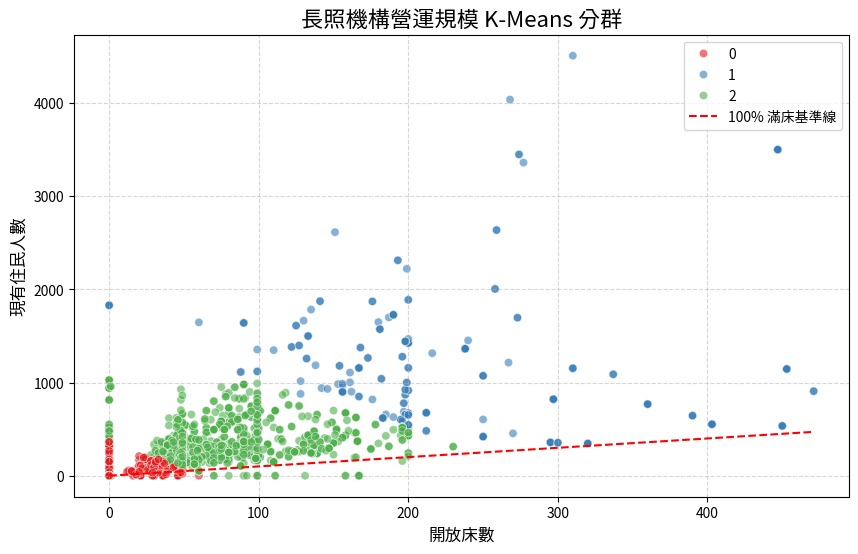


--- 4.2 政策模擬：高壓縣市之 A 級據點增設效益測試 ---


O_ABC,A,現狀壓力指數(每間A管理的BC數),模擬後_壓力指數,系統壓力下降幅度(%)
縣市名稱,,,,
彰化縣,17,94.88,73.32,22.73
高雄市,83,49.07,46.28,5.68
南投縣,23,46.48,38.18,17.86
嘉義縣,19,42.84,33.92,20.83
臺南市,56,36.88,33.85,8.20


In [23]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# --- 4.1 統計塑模：機構營運規模 K-Means 分群 ---
print("--- 4.1 統計塑模：機構營運規模 K-Means 分群 ---")
features = ['開放床數', '現有住民']
df_cluster = df_abc[features].copy()

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_abc['營運模式群集'] = kmeans.fit_predict(scaled_features)

cluster_summary = df_abc.groupby('營運模式群集')[features].mean().round(1)
cluster_summary['機構總數'] = df_abc['營運模式群集'].value_counts()
display(cluster_summary)

# --- 繪製 K-Means 分群散佈圖 ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_abc, x='開放床數', y='現有住民', hue='營運模式群集', palette='Set1', alpha=0.6)
plt.plot([0, df_abc['開放床數'].max()], [0, df_abc['開放床數'].max()], 'r--', label='100% 滿床基準線', linewidth=1.5)
plt.title('長照機構營運規模 K-Means 分群', fontsize=16, fontweight='bold')
plt.xlabel('開放床數', fontsize=12)
plt.ylabel('現有住民人數', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


# --- 4.2 政策模擬：高壓縣市之 A 級據點增設效益測試 ---
print("\n--- 4.2 政策模擬：高壓縣市之 A 級據點增設效益測試 ---")
sim_df = df_abc.groupby(['縣市名稱', 'O_ABC']).size().unstack(fill_value=0)
sim_df['A'] = sim_df['A'].replace(0, 1) # 避免分母為 0

# 計算現狀壓力指數 = (B級 + C級據點數) / A級據點數
sim_df['現有B+C總數'] = sim_df['B'] + sim_df['C']
sim_df['現狀壓力指數(每間A管理的BC數)'] = sim_df['現有B+C總數'] / sim_df['A']

top_pressure = sim_df.sort_values(by='現狀壓力指數(每間A管理的BC數)', ascending=False).head(5).copy()

# 模擬情境：為 5 個高壓縣市各增設 5 間 A 級據點
top_pressure['模擬後_A級數量'] = top_pressure['A'] + 5
top_pressure['模擬後_壓力指數'] = top_pressure['現有B+C總數'] / top_pressure['模擬後_A級數量']

# 計算系統壓力下降幅度 (%)
top_pressure['系統壓力下降幅度(%)'] = ((top_pressure['現狀壓力指數(每間A管理的BC數)'] - top_pressure['模擬後_壓力指數']) / top_pressure['現狀壓力指數(每間A管理的BC數)']) * 100

display(top_pressure[['A', '現狀壓力指數(每間A管理的BC數)', '模擬後_壓力指數', '系統壓力下降幅度(%)']].round(2))

### 深度數據洞察 (Data Insights)

綜合 K-Means 機構分群與 A 級據點壓力模擬結果，本研究得出以下具備高度政策參考價值的結論：

#### 一、 長照市場呈現「極端金字塔型」的營運結構 (K-Means 發現)
透過機器學習演算法，我們成功將全台三萬多家長照機構的營運模式分為三大類，揭露了長照市場的真實結構：
1. **群集 0 (微型社區與居家服務，佔比高達 94%)**：
   - 數量最多 (29,444 家)，平均床位近乎為 0。這群組主要由 B、C 級的居家服務、日照或社區共餐據點組成，完全體現了長照 2.0「在地老化、深入巷弄」的政策成果。
2. **群集 2 (中型住宿機構，佔比約 5%)**：
   - 數量次之 (1,561 家)，平均開放約 73 床，但現有住民僅約 32 人（佔床率約 43%）。這顯示中型機構目前可能處於轉型期，或在收容重度失能者的設備與量能上尚未完全發揮，存在資源閒置的優化空間。
3. **群集 1 (大型旗艦收容中心，佔比不到 1%)**：
   - 數量最稀缺 (僅 215 家)，但平均床位高達 228 床，且實際收容近 200 人（佔床率高達 87% 以上）。這群數據強烈暗示，具備完善醫療照護能力的大型住宿型機構處於**極度供不應求**的狀態，是未來長照硬體建設最需要補足的缺口。

#### 二、 政策資源投放的「邊際效益」差異極大 (Policy Simulation 發現)
在「高壓縣市增設 5 間 A 級據點」的政策模擬中，我們發現了齊頭式平等的盲點：
1. **資源匱乏區的極高投資報酬率 (ROI)**：
   - **彰化縣**目前的整合壓力居全台之冠（1 間 A 級據點需管理將近 95 間 B/C 級），但在模擬增設 5 間 A 級據點後，壓力瞬間**暴跌 22.73%**。同樣的，**嘉義縣**與**南投縣**在獲得 5 間據點的補助後，系統壓力也大幅下降了 17%~20%。
2. **大型都會區的邊際效益遞減**：
   - 反觀**高雄市**與**臺南市**，由於其 A 級據點的母體基數已經很大（分別為 83 間與 56 間），同樣投入 5 間據點的資源，對整體壓力的紓解幅度僅有 **5%~8%**。

**🎯 總結建議：**
未來的長照政策與預算分配，不應採用「各縣市平均分配」的齊頭式邏輯。數據強烈建議，中央應針對「A級基數小、整合壓力指數極高」的特定縣市（如彰化、嘉義、南投）進行**精準的針對性投資**，這將能以最小的預算成本，換取最大的區域長照系統穩定度。

## Part 5 : 專案總結與政策建議 (General Conclusion & Policy Recommendations)

本專案跳脫傳統單一資料集的數量統計，首創結合「長照機構供給端 (`abc.csv`)」與「各縣市高齡人口需求端 (`population_202602.csv`)」進行跨資料集深度探勘。透過地理視覺化、K-Means 機器學習與自建的政策模擬模型，我們對台灣長照 2.0 的現況提出了以下總結與具體建議：

### 🎯 核心研究總結

1. **「人口紅利」與「資源赤字」的空間錯配**
   雖然全台長照據點總數龐大，但散佈圖與熱力圖的交叉分析揭露了嚴重的結構性問題。例如「臺北市」面臨極大的高齡人口基數，但床位供給卻遠落後於趨勢線；而東部與偏鄉地區則面臨地理上的「資源沙漠」。這顯示長照資源的擴充並未精準對應到真實的人口需求分佈。
2. **住宿型長照機構的「隱形天花板」**
   K-Means 分群模型證實，全台高達 94% 的長照據點屬於無實體床位的微型社區據點。而具備收容能力的機構（無論中型或大型），其資料點幾乎完全貼合「100% 滿床基準線」。這表明台灣在「重度失能/住宿型」的長照資源上，已經觸及收容量能的極限天花板，處於嚴重供不應求的狀態。
3. **政策資源的「邊際效益」存在巨大落差**
   透過「A 級據點整合壓力指數」的模擬，我們發現若將資源（如增設 5 間 A 級據點）盲目投入在高雄、臺南等基數已大的都會區，對整體系統紓壓的效益僅有 5%~8%；但若精準投放於壓力極高的彰化、南投、嘉義，系統紓壓效益可高達 17%~22% 以上。

---

### 💡 給政府與業者的具體建議 (Actionable Insights)

基於上述數據洞察，本研究提出以下兩點實務建議：
* **從「齊頭式佈建」轉向「數據驅動的精準投資」**：
  中央政府在審核長照預算與前瞻計畫時，應引入類似本研究的「整合壓力指數」與「高齡資源充足率」作為 KPI。優先將經費補助與 A 級據點增設名額，導向**彰化、南投等高壓縣市**，以極大化預算的邊際效益 (ROI)。
* **政策誘因應轉向「中大型住宿型機構」**：
  既然 B、C 級的社區巷弄長照站已達普及規模（佔比 94%），未來的政策補貼、土地變更優惠與稅賦減免，應全力集中於鼓勵民間業者設立「中大型住宿型機構」，以打破目前滿床率 100% 的資源瓶頸，接住真正重度失能的高齡家庭。

**結語：**
長照 2.0 的下一階段，不應只是追求「據點數量的增加」，而必須仰賴數據科學進行「資源的精準優化」。本專案透過多維度的統計塑模，期盼能為台灣超高齡社會的政策擬定，提供一份客觀且具備實務價值的數據藍圖。